<a href="https://colab.research.google.com/github/zainazeem41472/Rice-Leaf-Disease-Classification/blob/main/hybridmodelfirstexperiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 150

TRAIN_DIR = "/content/drive/MyDrive/RiceLeafDisease12class/train"
VAL_DIR   = "/content/drive/MyDrive/RiceLeafDisease12class/validation"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_names)

Found 11996 images belonging to 12 classes.
Found 1049 images belonging to 12 classes.


In [ ]:
def residual_block(x, filters):

    shortcut = Conv2D(filters, 1, padding="same")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = LeakyReLU(0.1)(x)

    return x

In [ ]:
def dense_block(x, growth_rate=32):

    y = Conv2D(growth_rate, 3, padding="same", activation="relu")(x)
    x = Concatenate()([x, y])

    y = Conv2D(growth_rate, 3, padding="same", activation="relu")(x)
    x = Concatenate()([x, y])

    return x

In [ ]:
def se_block(x):

    filters = x.shape[-1]

    se = GlobalAveragePooling2D()(x)
    se = Dense(filters//4, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)

    se = Reshape((1,1,filters))(se)

    return Multiply()([x, se])

In [ ]:
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(64, 3, padding="same")(inputs)
x = BatchNormalization()(x)
x = LeakyReLU(0.1)(x)

# Block 1
x = residual_block(x, 64)
x = MaxPooling2D()(x)

# Block 2
x = dense_block(x)
x = se_block(x)
x = MaxPooling2D()(x)

# Block 3
x = residual_block(x, 128)
x = MaxPooling2D()(x)

# Block 4
x = dense_block(x)
x = se_block(x)
x = MaxPooling2D()(x)

# Block 5
x = residual_block(x, 256)

# Head
x = GlobalAveragePooling2D()(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.1)(x)
x = Dropout(0.5)(x)

x = Dense(256)(x)
x = LeakyReLU(0.1)(x)
x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

In [ ]:
optimizer = AdamW(learning_rate=0.0001, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.3),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 10968s 29s/step - accuracy: 0.6111 - loss: 1.4753 - val_accuracy: 0.1840 - val_loss: 3.1422 - learning_rate: 1.0000e-04
Epoch 2/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 280s 745ms/step - accuracy: 0.7696 - loss: 1.1272 - val_accuracy: 0.7579 - val_loss: 1.2318 - learning_rate: 1.0000e-04
Epoch 3/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 275s 734ms/step - accuracy: 0.8269 - loss: 1.0072 - val_accuracy: 0.7817 - val_loss: 1.0087 - learning_rate: 1.0000e-04
Epoch 4/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 272s 725ms/step - accuracy: 0.8635 - loss: 0.9261 - val_accuracy: 0.8484 - val_loss: 0.9418 - learning_rate: 1.0000e-04
Epoch 5/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 277s 737ms/step - accuracy: 0.8886 - loss: 0.8622 - val_accuracy: 0.8770 - val_loss: 0.8887 - learning_rate: 1.0000e-04
Epoch 6/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 276s 735ms/step - accuracy: 0.9022 - loss: 0.8302 - val_accuracy: 0.9237 - val_loss: 0.7425 - learning_rate: 1.0000e-04
Epoch 7/150
375/375 ━━━━━━━━━━━━━━

In [ ]:
model.save("/content/drive/MyDrive/final_hybrid_model_2.h5")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving raged stunt disease.jpeg to raged stunt disease.jpeg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224, 224))  # adjust size
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
class_idx = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


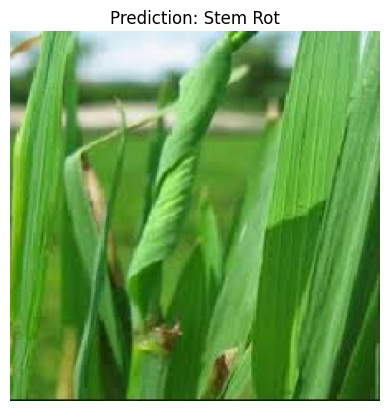

In [ ]:
class_names = ['Tungro','Stem Rot','Sheath Rot','Ragged Stunt Virus','narrow_brown_spot','leaf_scald','leaf_blast','irrelevant_pics','Hispa','healthy','brown_spot','bacterial_leaf_blight']  # change according to your dataset

plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {class_names[class_idx]}")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred = model.predict(val_generator)

y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

print("Accuracy:", accuracy_score(y_true, y_pred) * 100)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 506ms/step
Accuracy: 98.57006673021925

Classification Report:

                       precision    recall  f1-score   support

               Tungro       1.00      1.00      1.00        88
             Stem Rot       1.00      1.00      1.00        88
           Sheath Rot       1.00      0.99      0.99        81
   Ragged Stunt Virus       1.00      1.00      1.00        88
    narrow_brown_spot       1.00      1.00      1.00        88
           leaf_scald       1.00      1.00      1.00        88
           leaf_blast       0.96      0.92      0.94        88
      irrelevant_pics       0.95      0.95      0.95        88
                Hispa       0.99      1.00      0.99        88
              healthy       0.92      0.97      0.94        88
           brown_spot       1.00      1.00      1.00        88
bacterial_leaf_blight       1.00      1.00      1.00        88

             accuracy                           0.99      1049
            macro avg

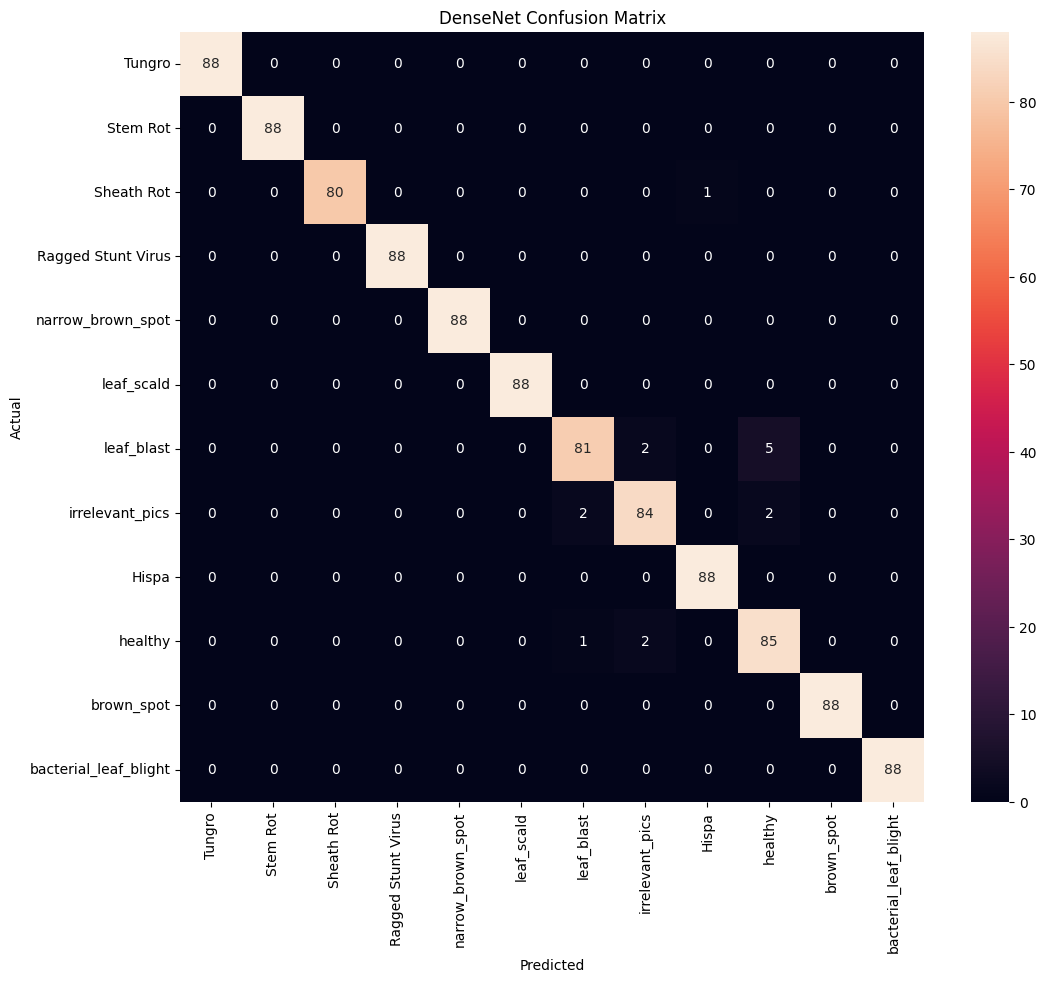

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet Confusion Matrix")
plt.show()